# Classic NLP Baselines

This notebook walks through:

1. **Implement a trigram language model (LM)** with add-*k* smoothing and computing **perplexity** on a test set.  
2. **Train a Logistic Regression** text classification baseline and do basic error analysis.

# Language Modelling using N-gram



## Load the data and split

In [3]:
import nltk
from nltk.corpus import brown

# NLTK data
nltk.download('brown') # Downloads the Brown Corpus files

# Dataset loading
sents = brown.sents(categories='news')

# Dataset splitting (80% train, 10% dev, 10% test)
TRAIN_SPLIT = 0.8
DEV_SPLIT = 0.1
TEST_SPLIT = 0.1

train_size = int(len(sents) * TRAIN_SPLIT)
dev_size = int(len(sents) * DEV_SPLIT)

train_sents = sents[:train_size]
dev_sents = sents[train_size:train_size + dev_size]
test_sents = sents[train_size + dev_size:]

print(f"Training Sentences: {len(train_sents)}")
print(f"Development Sentences: {len(dev_sents)}")
print(f"Testing Sentences: {len(test_sents)}")

Training Sentences: 3698
Development Sentences: 462
Testing Sentences: 463


[nltk_data] Downloading package brown to
[nltk_data]     /Users/sigurdurhaukur/nltk_data...
[nltk_data]   Package brown is already up-to-date!


##Trigram Model Implementation
A trigram model approximates the probability of a word given its previous two words:

$$P( w_{i}| w_{i-2}, w_{i-1}) = \frac{C(w_{i-2}, w_{i-1}, w_{i})}{C(w_{i-2}, w_{i-1})}$$

Laplace (Add-1) Smoothing is implemented to handle the sparsity problem.

$$
P(w_i \mid w_{i-2}, w_{i-1}) =
\frac{C(w_{i-2}, w_{i-1}, w_i) + k}{C(w_{i-2}, w_{i-1}) + k \cdot |V|}
$$

Where $|V|$ is vocabulary size.

In [8]:
from collections import defaultdict
import numpy as np
import math

class TrigramLanguageModel:
    def __init__(self):
        self.bigram_counts = defaultdict(int)
        self.trigram_counts = defaultdict(int)
        self.vocab = set()

    def preprocess(self, sentence):
        # Add start/end tokens for trigram context
        return ["<s>"] + [w.lower() for w in sentence] + ["</s>"]

    def train(self, sentences):
        print("Training Trigram Model...")
        for sentence in sentences:
            tokens = self.preprocess(sentence)
            self.vocab.update(tokens)

            # Count Bigrams and Trigrams
            for i in range(2, len(tokens)):
                w_prev2 = tokens[i-2]
                w_prev1 = tokens[i-1]
                w_curr = tokens[i]

                self.bigram_counts[(w_prev2, w_prev1)] += 1
                self.trigram_counts[(w_prev2, w_prev1, w_curr)] += 1

        self.vocab_size = len(self.vocab)
        print(f"Training complete. Vocab size: {self.vocab_size}")

    def get_prob(self, w_prev2, w_prev1, w_curr, smoothing_k=1.0):
        """
        Calculates P(w_curr | w_prev2, w_prev1) with Add-k smoothing.
        """
        # Count the trigrams and bigrams
        trigram_count = self.trigram_counts[(w_prev2, w_prev1, w_curr)]
        bigram_count = self.bigram_counts[(w_prev2, w_prev1)]

        # Apply smoothing formula
        prob = (trigram_count + smoothing_k) / (bigram_count + smoothing_k * self.vocab_size)

        return prob

In [9]:
# Extended N-gram model with linear interpolation
class InterpolatedTrigramLanguageModel(TrigramLanguageModel):
    def __init__(self, lambda1=0.1, lambda2=0.3, lambda3=0.6):
        super().__init__()
        self.lambda1 = lambda1
        self.lambda2 = lambda2
        self.lambda3 = lambda3

    def get_prob(self, w_prev2, w_prev1, w_curr, smoothing_k=1.0):
        """
        Calculates P(w_curr | w_prev2, w_prev1) with linear interpolation.
        """
        # Get trigram probability
        trigram_prob = super().get_prob(w_prev2, w_prev1, w_curr, smoothing_k)

        # Get bigram probability
        bigram_count = self.bigram_counts[(w_prev1, w_curr)]
        unigram_count = self.bigram_counts[(w_curr)]
        bigram_prob = (bigram_count + smoothing_k) / (unigram_count + smoothing_k * self.vocab_size)

        # Get unigram probability
        unigram_prob = (self.bigram_counts[(w_curr)] + smoothing_k) / (sum(self.bigram_counts.values()) + smoothing_k * self.vocab_size)

        # Linear interpolation
        prob = self.lambda1 * trigram_prob + self.lambda2 * bigram_prob + self.lambda3 * unigram_prob

        return prob

In [10]:
# Initialize and Train
lm = TrigramLanguageModel()
lm.train(train_sents)

Training Trigram Model...
Training complete. Vocab size: 11425


In [11]:
# Initialize and Train Interpolated Model
interpolated_lm = InterpolatedTrigramLanguageModel()
interpolated_lm.train(train_sents)

Training Trigram Model...
Training complete. Vocab size: 11425


### Exercise

Extend the class above and add linear interpolation:

$$
P(w_{i}|w_{i-2}, w_{i-1})=\lambda_{1}P(w_{i}|w_{i-2}, w_{i-1})+\lambda_{2}P(w_{i}|w_{i-1})+\lambda_{3}P(w_{i})
$$

## Perplexity

Perplexity is the inverse probability of the test set, normalized by the number of words. (Lower perplexity indicates a better model)
$$
\mathrm{PP}(w_{1:N})=\left(\prod_{i=1}^{N} P\!\left(w_i \mid w_{i-2},\,w_{i-1}\right)\right)^{-1/N}
$$


To prevent numerical underflow, we sum log probabilities:
$$
\mathrm{PP}(W)=\exp\!\left(-\frac{1}{N}\sum_{i=1}^{N}\ln P\!\left(w_i \mid h_i\right)\right)
$$

In [12]:
def compute_perplexity(model, sentences, k = 1.0):
    log_prob_sum = 0
    N = 0

    for sentence in sentences:
        tokens = model.preprocess(sentence)

        for i in range(2, len(tokens)):
            w_prev2 = tokens[i-2]
            w_prev1 = tokens[i-1]
            w_curr = tokens[i]

            prob = model.get_prob(w_prev2, w_prev1, w_curr, k)

            # Sum log probabilities (using natural log)
            log_prob_sum += math.log(prob)
            N += 1

    # Calculate Perplexity
    perplexity = math.exp(-log_prob_sum / N)
    return perplexity

In [15]:
# Evaluate
print("Evaluating Trigram Model...\n")
train_pp = compute_perplexity(lm, train_sents)
test_pp = compute_perplexity(lm, test_sents)

print(f"Train Perplexity: {train_pp:.2f}")
print(f"Test Perplexity:  {test_pp:.2f}\n\n")

# Evaluate Interpolated Model
print("Evaluating Interpolated Trigram Model...\n")
interpolated_train_pp = compute_perplexity(interpolated_lm, train_sents)
interpolated_test_pp = compute_perplexity(interpolated_lm, test_sents)

print(f"Interpolated Train Perplexity: {interpolated_train_pp:.2f}")
print(f"Interpolated Test Perplexity:  {interpolated_test_pp:.2f}\n\n")

# Simple comparison of models
print("\nModel Comparison:")
print(f"Trigram Model - Train PP: {train_pp:.2f}, Test PP: {test_pp:.2f}")
print(f"Interpolated Trigram Model - Train PP: {interpolated_train_pp:.2f}, Test PP: {interpolated_test_pp:.2f}")

Evaluating Trigram Model...
Train Perplexity: 4910.19
Test Perplexity:  9762.68
Evaluating Interpolated Trigram Model...
Interpolated Train Perplexity: 6812.41
Interpolated Test Perplexity:  11141.95

Model Comparison:
Trigram Model - Train PP: 4910.19, Test PP: 9762.68
Interpolated Trigram Model - Train PP: 6812.41, Test PP: 11141.95


Why is the Test Perplexity significantly higher than the Train Perplexity? How would increasing the smoothing parameter k affect this?

k          | Train PP     | Test PP     
----------------------------------------
0.001      | 12.78        | 935.79      
0.005      | 61.34        | 1749.03     
0.01       | 121.09       | 2294.86     
0.02       | 238.81       | 3010.96     
0.05       | 581.07       | 4296.47     
0.1        | 1119.76      | 5580.11     
0.2        | 2093.44      | 7144.87     
0.5        | 4375.39      | 9492.14     
1.0        | 6812.41      | 11141.95    
2.0        | 9239.96      | 12246.39    
5.0        | 11141.07     | 12535.82    
10.0       | 11495.92     | 12184.31    


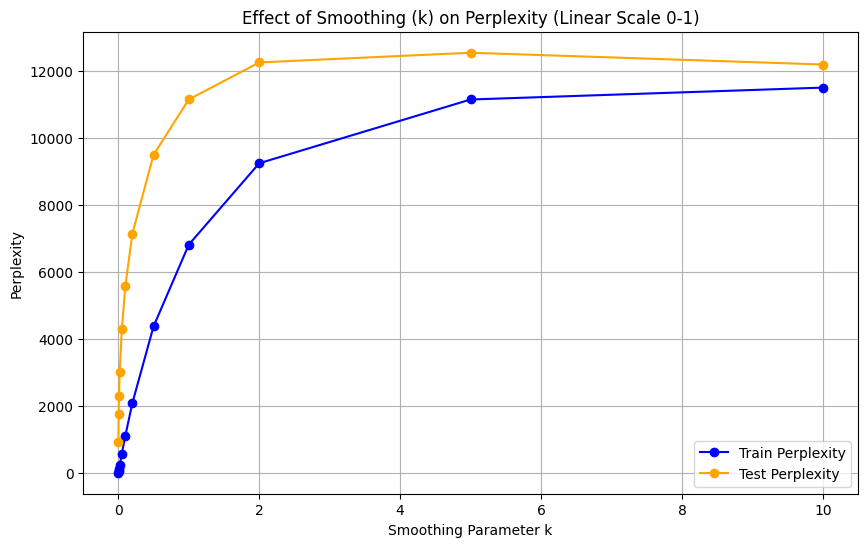

In [17]:
import matplotlib.pyplot as plt

k_values_linear = [0.001, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0]

train_perplexities = []
test_perplexities = []

print(f"{'k':<10} | {'Train PP':<12} | {'Test PP':<12}")
print("-" * 40)

for k in k_values_linear:
    # Compute perplexities for each k using the interpolated trigram model
    train_pp = compute_perplexity(interpolated_lm, train_sents, k)
    test_pp = compute_perplexity(interpolated_lm, test_sents, k)

    train_perplexities.append(train_pp)
    test_perplexities.append(test_pp)

    print(f"{k:<10} | {train_pp:<12.2f} | {test_pp:<12.2f}")

plt.figure(figsize=(10, 6))

plt.plot(k_values_linear, train_perplexities, marker='o', label='Train Perplexity', color='blue')
plt.plot(k_values_linear, test_perplexities, marker='o', label='Test Perplexity', color='orange')

plt.xlabel('Smoothing Parameter k')
plt.ylabel('Perplexity')
plt.title('Effect of Smoothing (k) on Perplexity (Linear Scale 0-1)')
plt.legend()
plt.grid(True)
plt.show()

In [29]:
# Generate text using the trained trigram model
def generate_text(model, start_tokens, max_length=20):
    generated = start_tokens.copy()

    for _ in range(max_length):
        w_prev2, w_prev1 = generated[-2], generated[-1]

        # Get the next word probabilities for all words in the vocab
        next_word_probs = {w: model.get_prob(w_prev2, w_prev1, w) for w in model.vocab}

        # Choose the word with the highest probability
        next_word = max(next_word_probs, key=next_word_probs.get)
        generated.append(next_word)

        if next_word == "</s>":
            break

    return ' '.join(generated[1:-1])  # Exclude <s> and </s>


start_tokens = "New York is".split()
generated_text = generate_text(lm, start_tokens, max_length=50)
print(f"Generated Text: {generated_text}")

# Generate text using the interpolated trigram model
generated_text_interpolated = generate_text(interpolated_lm, start_tokens, max_length=50)
print(f"Generated Text (Interpolated): {generated_text_interpolated}")

Generated Text: York is conventional conventional conventional conventional conventional conventional conventional conventional conventional conventional conventional conventional conventional conventional conventional conventional conventional conventional conventional conventional conventional conventional conventional conventional conventional conventional conventional conventional conventional conventional conventional conventional conventional conventional conventional conventional conventional conventional conventional conventional conventional conventional conventional conventional conventional conventional conventional conventional conventional
Generated Text (Interpolated): York is a year .


# Text Classification using Logistic Regression

## Load the data

In [18]:
from sklearn.datasets import fetch_20newsgroups

categories = ['sci.space', 'rec.autos', 'comp.graphics', 'talk.politics.mideast']

newsgroups_train =  fetch_20newsgroups(subset='train', categories=categories)
newsgroups_test = fetch_20newsgroups(subset='test', categories=categories)

print(f"Train samples: {len(newsgroups_train.data)}")
print(f"Test samples: {len(newsgroups_test.data)}")

Train samples: 2335
Test samples: 1555


In [19]:
import pandas as pd

newsgroup_full = fetch_20newsgroups(subset="all", categories=None)
df = pd.DataFrame({
    "text" : newsgroup_full.data,
    "target_id" : newsgroup_full.target,
    "category" : [newsgroup_full.target_names[i] for i in newsgroup_full.target]
})
df.head()

,text,target_id,category
0,From: Mamatha Devineni Ratnam <mr47+@andrew.cm...,10,rec.sport.hockey
1,From: mblawson@midway.ecn.uoknor.edu (Matthew ...,3,comp.sys.ibm.pc.hardware
2,From: hilmi-er@dsv.su.se (Hilmi Eren)\nSubject...,17,talk.politics.mideast
3,From: guyd@austin.ibm.com (Guy Dawson)\nSubjec...,3,comp.sys.ibm.pc.hardware
4,From: Alexander Samuel McDiarmid <am2o+@andrew...,4,comp.sys.mac.hardware


## Vectorize texts into sparse TF-IDF features and split the data

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english', max_features=5000)

X_train = tfidf.fit_transform(newsgroups_train.data)
X_test = tfidf.transform(newsgroups_test.data)

# Define target train and test sets
y_train = newsgroups_train.target
y_test = newsgroups_test.target

## Train logistic regression

In [ ]:
from sklearn.linear_model import LogisticRegression

# Train logistic regression
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

## Evaluate on dev set

                       precision    recall  f1-score   support

        comp.graphics       0.92      0.95      0.94       389
            rec.autos       0.94      0.97      0.96       396
            sci.space       0.96      0.94      0.95       394
talk.politics.mideast       0.99      0.95      0.97       376

             accuracy                           0.95      1555
            macro avg       0.95      0.95      0.95      1555
         weighted avg       0.95      0.95      0.95      1555



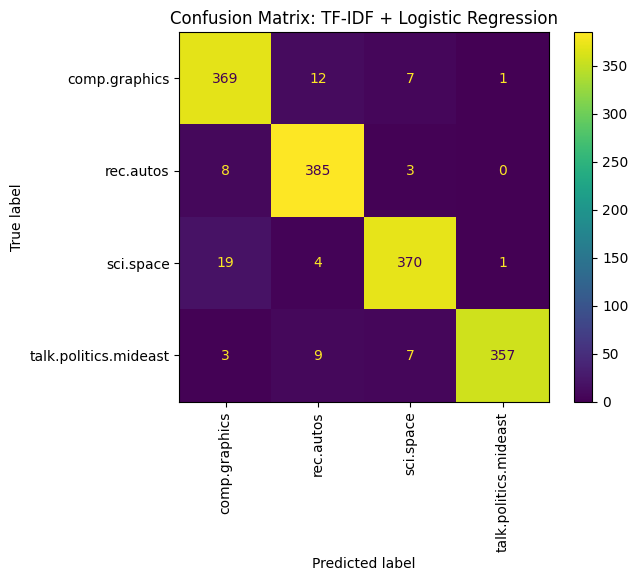

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Make predictions
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=newsgroups_train.target_names))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=newsgroups_train.target_names)
disp.plot(xticks_rotation='vertical')
plt.title("Confusion Matrix: TF-IDF + Logistic Regression")
plt.show()

## Error analysis

In [23]:
df_predictions = pd.DataFrame({
    'text': newsgroups_test.data,
    'true_label': [newsgroups_train.target_names[i] for i in y_test],
    'pred_label': [newsgroups_train.target_names[i] for i in y_pred]
})

errors = df_predictions[df_predictions['true_label'] != df_predictions['pred_label']]

print(f"Total Errors: {len(errors)}")
print("Displaying first 20 misclassifications:")

#pd.set_option('display.max_colwidth', 150)
display(errors.head(20))

Total Errors: 74
Displaying first 20 misclassifications:


,text,true_label,pred_label
16,From: born@scepter.ibm.com (Christopher J. Bor...,rec.autos,comp.graphics
47,From: binglis@health.ufl.edu (binglis)\nSubjec...,sci.space,comp.graphics
53,From: rousself@cicb.fr ( Frank ROUSSEL )\nSubj...,sci.space,comp.graphics
85,From: curdm@uxa.ecn.bgu.edu (Richard Mancuso)\...,comp.graphics,rec.autos
103,From: clements@vax.oxford.ac.uk\nSubject: Re: ...,sci.space,comp.graphics
111,From: khalid@bunce.hw.stratus.com (Khalid Chis...,talk.politics.mideast,rec.autos
153,From: f54oguocha@edison.usask.ca\nSubject: RE:...,talk.politics.mideast,rec.autos
168,From: cza@troy.cc.bellcore.com (C. Akgun)\nSub...,talk.politics.mideast,rec.autos
195,From: roy@mchip00.med.nyu.edu (Roy Smith)\nSub...,comp.graphics,rec.autos
208,From: wingo%cspara.decnet@Fedex.Msfc.Nasa.Gov\...,sci.space,comp.graphics
